# Аутентификация банкнот (SVM)

**Датасет:** [Bank Note Authentication](https://www.kaggle.com/datasets/ritesaluja/bank-note-authentication-uci-data) - 1372 банкноты, 4 признака (извлечены из изображения: дисперсия, асимметрия, эксцесс, энтропия вейвлет-преобразования)
**Задача:** бинарная классификация - настоящая (0) или поддельная (1) банкнота

## 1. Краткая теория

**SVM** ищет гиперплоскость с максимальным зазором (margin) между классами. Для нелинейных данных используется ядерный трюк (RBF, polynomial). Параметр $C$ управляет компромиссом между шириной зазора и ошибками, $\gamma$ - радиусом влияния каждого объекта.

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i \quad \text{при} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 - \xi_i$$

Подробная теория - в [README.md](README.md).

## 2. Загрузка данных

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import StandardScaler
import kagglehub

path = kagglehub.dataset_download('ritesaluja/bank-note-authentication-uci-data')
df = pd.read_csv(f'{path}/BankNote_Authentication.csv')

In [2]:
print(f'Размер: {df.shape[0]} записей, {df.shape[1]} столбцов')
df.head()

Размер: 1372 записей, 5 столбцов


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


## 3. Первичный анализ

In [4]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


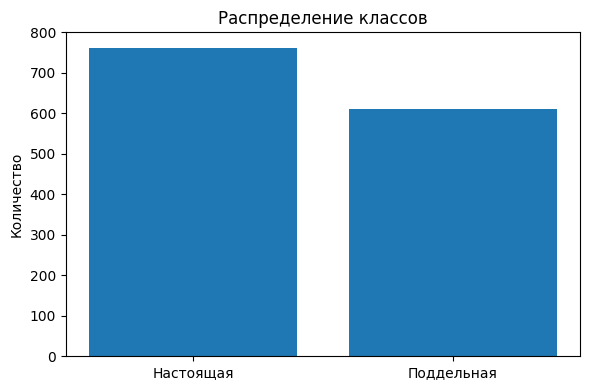

Настоящие: 762, Поддельные: 610 (соотношение 1.25:1)


In [5]:
# распределение классов
class_names = ['Настоящая', 'Поддельная']
counts = df['class'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts.values)
plt.ylabel('Количество')
plt.title('Распределение классов')
plt.tight_layout()
plt.show()

print(f'Настоящие: {counts[0]}, Поддельные: {counts[1]} (соотношение {counts[0]/counts[1]:.2f}:1)')

Классы умеренно сбалансированы, accuracy адекватна как метрика.

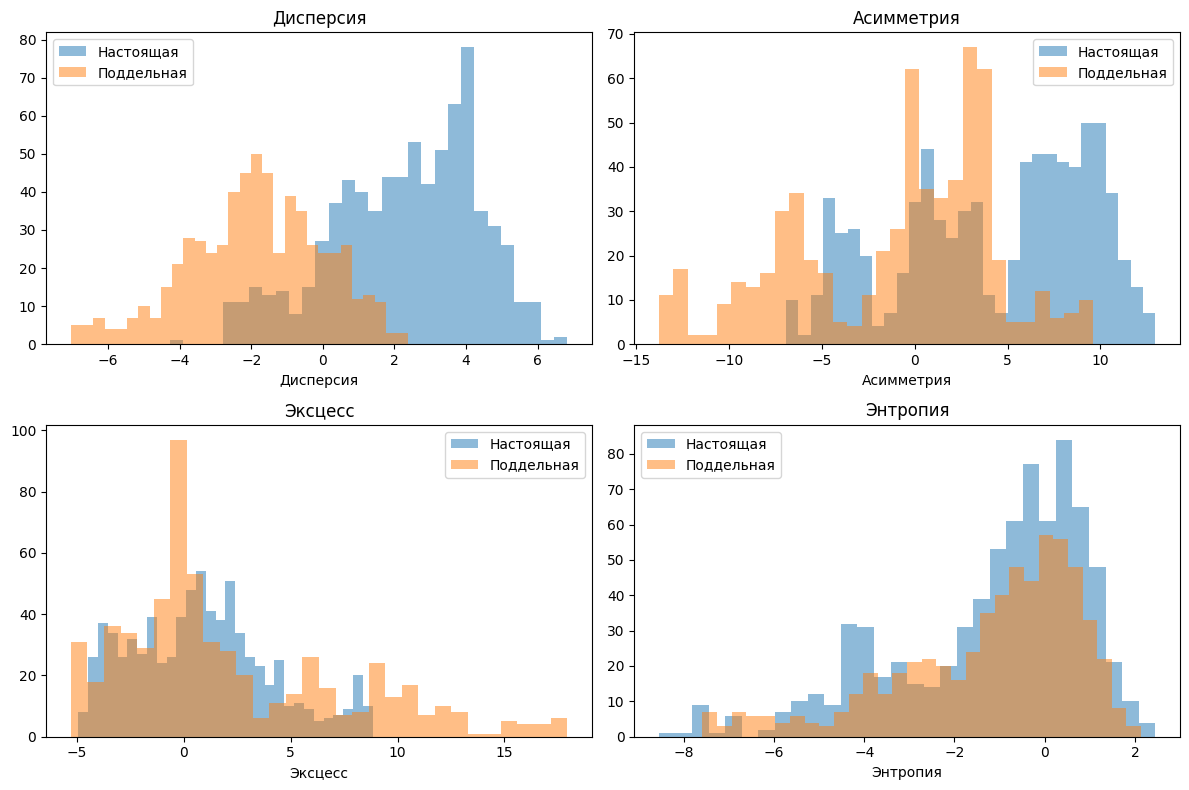

In [6]:
# распределение признаков по классам
col_names = {'variance': 'Дисперсия', 'skewness': 'Асимметрия',
             'curtosis': 'Эксцесс', 'entropy': 'Энтропия'}
features = ['variance', 'skewness', 'curtosis', 'entropy']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, features):
    for c in [0, 1]:
        data = df[df['class'] == c][feat]
        ax.hist(data, bins=30, alpha=0.5, label=class_names[c])
    ax.set_title(col_names[feat])
    ax.set_xlabel(col_names[feat])
    ax.legend()
plt.tight_layout()
plt.show()

Дисперсия - лучший разделитель: у настоящих банкнот значения выше. Энтропия тоже различается, но с большим перекрытием. Асимметрия и эксцесс менее дискриминативны.

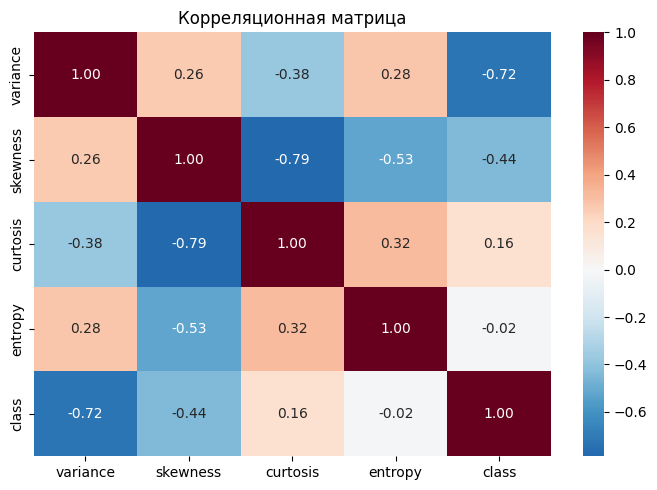

In [7]:
# корреляционная матрица
corr = df.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Дисперсия сильнее всего коррелирует с целевой переменной (r ~ -0.73). Признаки слабо коррелируют друг с другом - хорошо для SVM.

In [8]:
# пропуски
print(f'Пропуски: {df.isnull().sum().sum()}')

Пропуски: 0


## 4. Предобработка

In [9]:
X = df[features].values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM требует масштабирования
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Распределение в train: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Распределение в test:  {dict(zip(*np.unique(y_test, return_counts=True)))}')

X_train: (1097, 4), X_test: (275, 4)
Распределение в train: {np.int64(0): np.int64(609), np.int64(1): np.int64(488)}
Распределение в test:  {np.int64(0): np.int64(153), np.int64(1): np.int64(122)}


## 5. Обучение модели

### Baseline (RBF ядро по умолчанию)

In [10]:
svm_baseline = SVC(random_state=42)
svm_baseline.fit(X_train, y_train)

print(f'Accuracy train: {svm_baseline.score(X_train, y_train):.4f}')
print(f'Accuracy test:  {svm_baseline.score(X_test, y_test):.4f}')
print(f'Опорных векторов: {svm_baseline.n_support_.sum()} из {len(X_train)}')

Accuracy train: 1.0000
Accuracy test:  1.0000
Опорных векторов: 91 из 1097


Baseline с RBF ядром и C=1, gamma='scale' показал идеальный результат: accuracy=1.0 на train и test. Всего 91 опорный вектор из 1097 (8.3%) - модель компактна.

### Сравнение ядер

In [11]:
# сравнение ядер
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_names = {'linear': 'Линейное', 'poly': 'Полиномиальное',
                'rbf': 'RBF', 'sigmoid': 'Сигмоидное'}

print(f'{"Ядро":<20} {"Train":>8} {"Test":>8} {"SV":>6}')
print('-' * 44)
for k in kernels:
    svm = SVC(kernel=k, random_state=42)
    svm.fit(X_train, y_train)
    tr = svm.score(X_train, y_train)
    te = svm.score(X_test, y_test)
    sv = svm.n_support_.sum()
    print(f'{kernel_names[k]:<20} {tr:>8.4f} {te:>8.4f} {sv:>6}')

Ядро                    Train     Test     SV
--------------------------------------------
Линейное               0.9863   0.9745     62
Полиномиальное         0.9881   0.9818    279
RBF                    1.0000   1.0000     91
Сигмоидное             0.7703   0.7855    284


RBF ядро - идеальный результат (1.0). Линейное (0.97) и полиномиальное (0.98) чуть хуже - данные не полностью линейно разделимы. Сигмоидное ядро значительно уступает (0.79).

### Подбор гиперпараметров (RBF)

In [12]:
# GridSearchCV для RBF
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
}

grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

print(f'Лучшие параметры: {grid.best_params_}')
print(f'CV accuracy: {grid.best_score_:.4f}')
print(f'Test accuracy: {grid.best_estimator_.score(X_test, y_test):.4f}')

Лучшие параметры: {'C': 1, 'gamma': 'scale'}
CV accuracy: 1.0000
Test accuracy: 1.0000


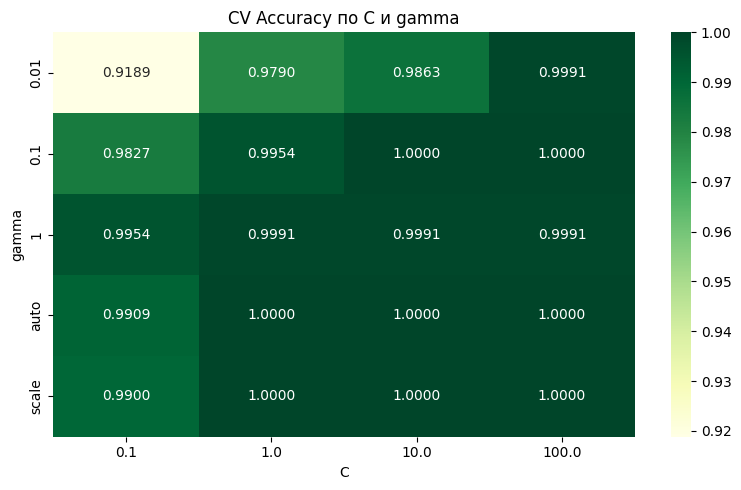

In [13]:
# тепловая карта accuracy по C и gamma
results = pd.DataFrame(grid.cv_results_)
c_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 'auto', 0.01, 0.1, 1]

pivot = results.pivot_table(
    values='mean_test_score',
    index='param_gamma', columns='param_C'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn')
plt.title('CV Accuracy по C и gamma')
plt.xlabel('C')
plt.ylabel('gamma')
plt.tight_layout()
plt.show()

Лучшие результаты при умеренных C и gamma. Слишком большой gamma (=1) приводит к переобучению, слишком малый C (=0.1) - к недообучению.

In [14]:
svm_best = grid.best_estimator_
print(f'Опорных векторов: {svm_best.n_support_} (класс 0: {svm_best.n_support_[0]}, класс 1: {svm_best.n_support_[1]})')
print(f'Всего: {svm_best.n_support_.sum()} из {len(X_train)} ({svm_best.n_support_.sum()/len(X_train)*100:.1f}%)')

Опорных векторов: [44 47] (класс 0: 44, класс 1: 47)
Всего: 91 из 1097 (8.3%)


## 6. Оценка качества

In [15]:
# classification report
y_pred = svm_best.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   Настоящая       1.00      1.00      1.00       153
  Поддельная       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



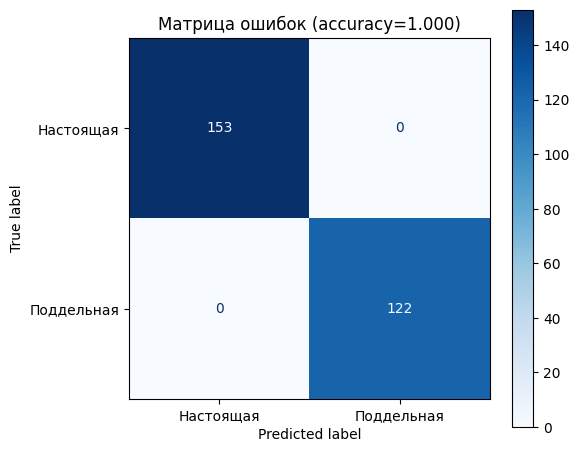

Ошибок: 0 из 275


In [16]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues')
plt.title(f'Матрица ошибок (accuracy={svm_best.score(X_test, y_test):.3f})')
plt.tight_layout()
plt.show()

print(f'Ошибок: {(y_pred != y_test).sum()} из {len(y_test)}')

Модель не допустила ни одной ошибки (0 из 275). Precision и recall равны 1.0 для обоих классов.

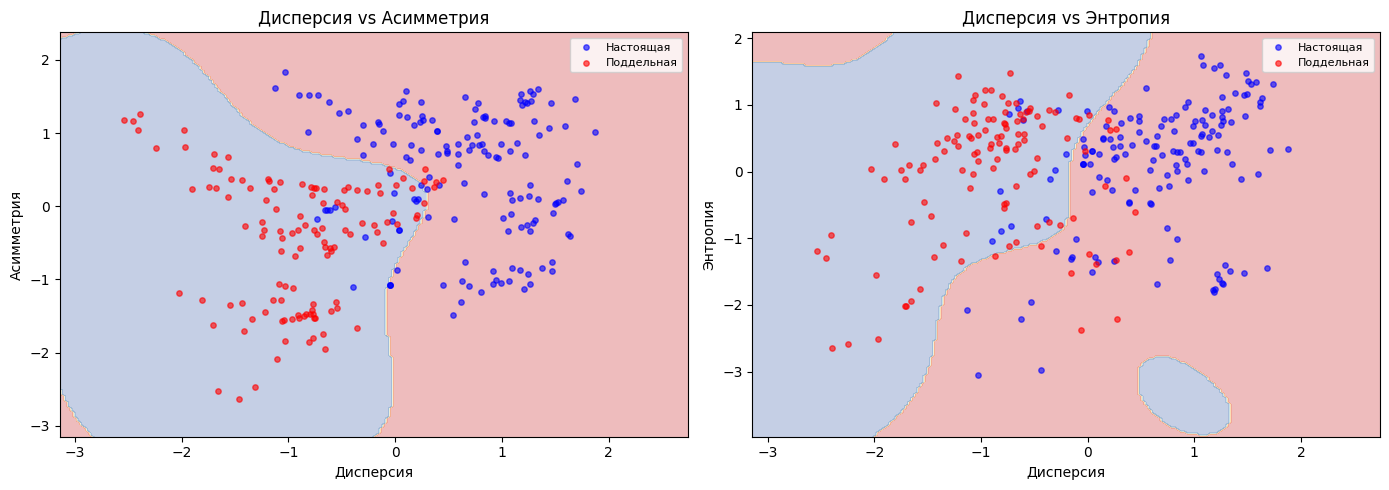

In [17]:
# визуализация границ решений (по двум главным признакам)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# дисперсия vs асимметрия
for ax, (f1, f2) in zip(axes, [(0, 1), (0, 3)]):
    # обучаем SVM на двух признаках для визуализации
    svm_2d = SVC(kernel='rbf', C=grid.best_params_['C'],
                 gamma=grid.best_params_['gamma'], random_state=42)
    svm_2d.fit(X_train[:, [f1, f2]], y_train)

    # сетка для контура
    x_min, x_max = X_train[:, f1].min() - 0.5, X_train[:, f1].max() + 0.5
    y_min, y_max = X_train[:, f2].min() - 0.5, X_train[:, f2].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    for c, color, name in [(0, 'blue', 'Настоящая'), (1, 'red', 'Поддельная')]:
        mask = y_test == c
        ax.scatter(X_test[mask, f1], X_test[mask, f2],
                   c=color, s=15, alpha=0.6, label=name)

    f_names = [col_names[features[f1]], col_names[features[f2]]]
    ax.set_xlabel(f_names[0])
    ax.set_ylabel(f_names[1])
    ax.set_title(f'{f_names[0]} vs {f_names[1]}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Границы решений нелинейные благодаря RBF ядру. На паре Дисперсия-Асимметрия классы разделяются хорошо, на паре Дисперсия-Энтропия граница более сложная.

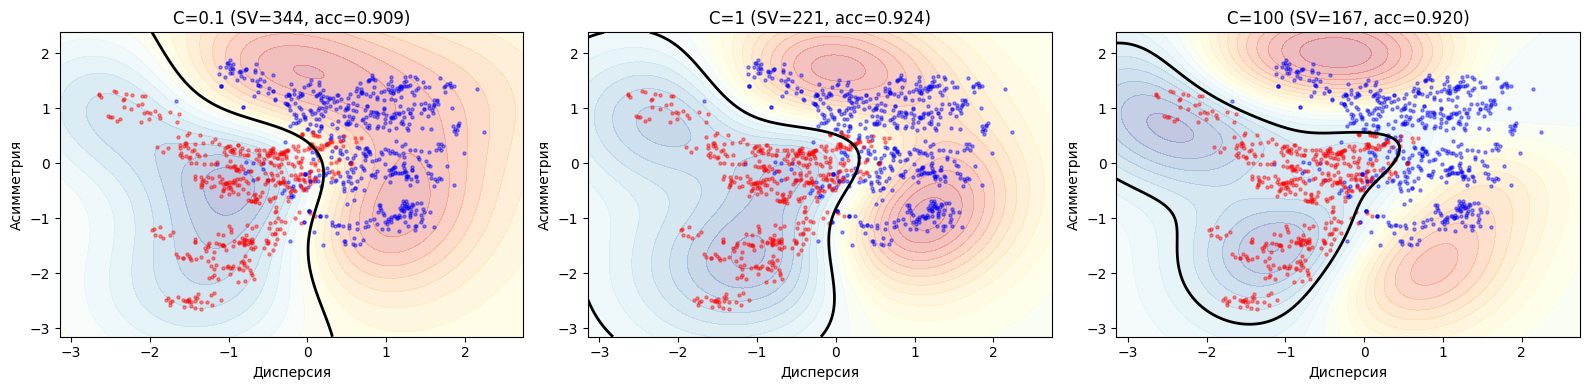

In [18]:
# влияние C на margin (визуализация на двух признаках)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
f1, f2 = 0, 1

for ax, c_val in zip(axes, [0.1, 1, 100]):
    svm_c = SVC(kernel='rbf', C=c_val, gamma=grid.best_params_['gamma'], random_state=42)
    svm_c.fit(X_train[:, [f1, f2]], y_train)

    x_min, x_max = X_train[:, f1].min() - 0.5, X_train[:, f1].max() + 0.5
    y_min, y_max = X_train[:, f2].min() - 0.5, X_train[:, f2].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = svm_c.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=20, alpha=0.3, cmap='RdYlBu')
    ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)

    for c, color in [(0, 'blue'), (1, 'red')]:
        mask = y_train == c
        ax.scatter(X_train[mask, f1], X_train[mask, f2], c=color, s=5, alpha=0.4)

    sv_count = svm_c.n_support_.sum()
    acc = svm_c.score(X_test[:, [f1, f2]], y_test)
    ax.set_title(f'C={c_val} (SV={sv_count}, acc={acc:.3f})')
    ax.set_xlabel(col_names[features[f1]])
    ax.set_ylabel(col_names[features[f2]])

plt.tight_layout()
plt.show()

При малом C (=0.1) граница гладкая, много опорных векторов - широкий margin. При большом C (=100) граница более сложная, меньше опорных векторов - модель точнее подстраивается под данные.